In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import scipy.stats as stats
import seaborn as sns

plt.style.use("science")

In [8]:
data = pd.read_csv("results/rKAN/results-rKAN2-IO-2025-01-03 00_05_03.045426.csv")

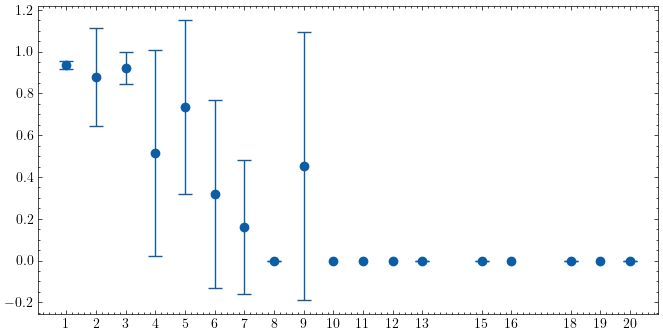

In [10]:
# plt.plot(data['params_depth'], data['value'], 'o')

mean_values = data.groupby("params_depth")["value"].mean()
std_values = data.groupby("params_depth")["value"].std()

plt.figure(figsize=(8, 4))
plt.errorbar(mean_values.index, mean_values, yerr=std_values, fmt="o", capsize=5)
plt.xticks(mean_values.index, mean_values.index)
None

In [11]:
neurons_columns = data.filter(regex="^params_neurons_layer_")
data["total_params_neurons"] = data[neurons_columns.columns].sum(axis=1)

neurons_columns2 = data.filter(regex="^params_grids_")
data["total_params_grids"] = data[neurons_columns2.columns].sum(axis=1)

In [12]:
data["total_params_neurons_bins"] = pd.cut(
    data["total_params_neurons"], 10, labels=False
)

data["total_params_grids_bins"] = pd.cut(data["total_params_grids"], 10, labels=False)

data["total_params_neurons_bins2"] = pd.cut(data["total_params_neurons"], 10)

data["total_params_grids_bins2"] = pd.cut(data["total_params_grids"], 10)

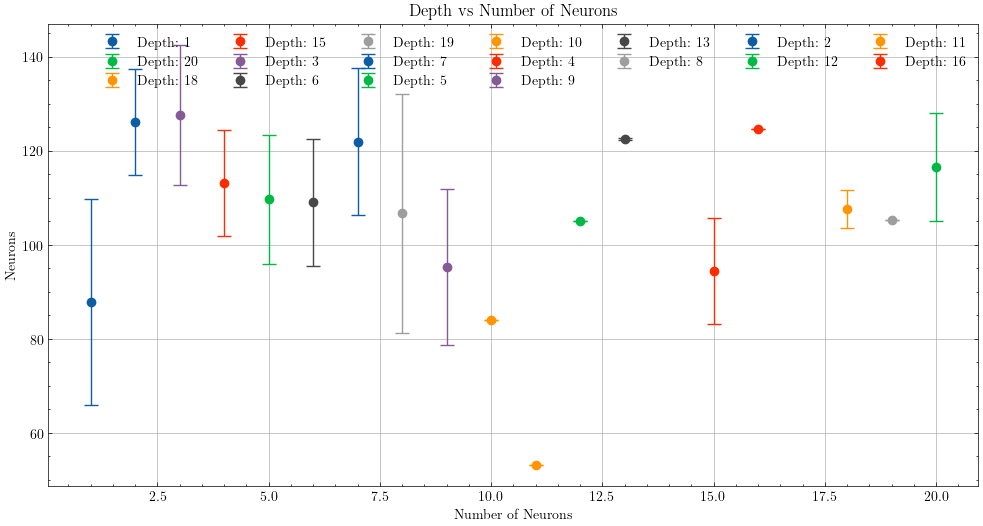

In [13]:
df = data
# Assuming 'df' is your DataFrame
# Extracting the columns for params_neurons_layer_* and accuracy
neurons_columns = df.filter(regex="^params_neurons_layer_")
accuracy_column = "value"  # Replace with the actual name of your accuracy column

# Create a figure for plotting
plt.figure(figsize=(12, 6))

# Loop through each depth and plot accuracy against the number of neurons
for depth in df["params_depth"].unique():
    # Filter the DataFrame for the current depth
    depth_data = df[df["params_depth"] == depth]

    # Calculate the mean accuracy for each number of neurons
    mean_accuracy = depth_data[neurons_columns.columns].mean(axis=1)
    m = np.mean(mean_accuracy)
    s = (
        np.std(mean_accuracy)
        / np.sqrt(len(mean_accuracy))
        * stats.norm.ppf(1 - (1 - 0.95) / 2)
    )
    # Plotting
    plt.errorbar(depth, m, yerr=s, fmt="o", capsize=5, label=f"Depth: {depth}")

plt.title("Depth vs Number of Neurons")
plt.xlabel("Number of Neurons")
plt.ylabel("Neurons")
plt.legend(ncols=7)
plt.grid()
plt.show()

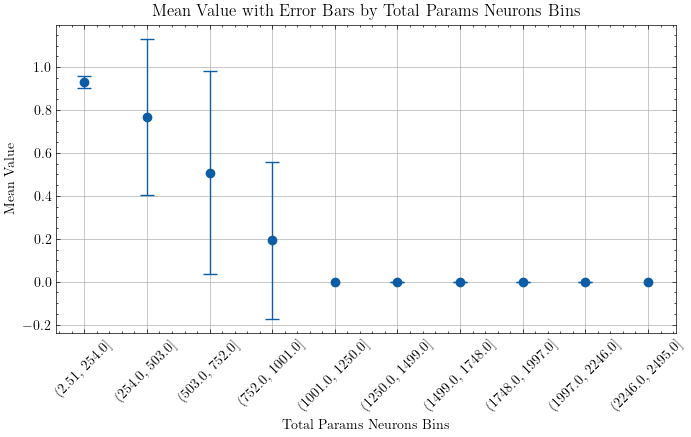

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'data' is your DataFrame and you have already created the bins
data["total_params_neurons_bins"] = pd.cut(
    data["total_params_neurons"], 10, labels=False
)
data["total_params_neurons_bins2"] = pd.cut(data["total_params_neurons"], 10)

mean_values = data.groupby("total_params_neurons_bins")["value"].mean()
std_values = data.groupby("total_params_neurons_bins")["value"].std()

plt.figure(figsize=(8, 4))
plt.errorbar(mean_values.index, mean_values, yerr=std_values, fmt="o", capsize=5)

# Set the x-ticks to the bin labels
plt.xticks(
    mean_values.index,
    [f"{interval}" for interval in data["total_params_neurons_bins2"].cat.categories],
    rotation=45,
)

plt.title("Mean Value with Error Bars by Total Params Neurons Bins")
plt.xlabel("Total Params Neurons Bins")
plt.ylabel("Mean Value")
plt.grid()
plt.show()

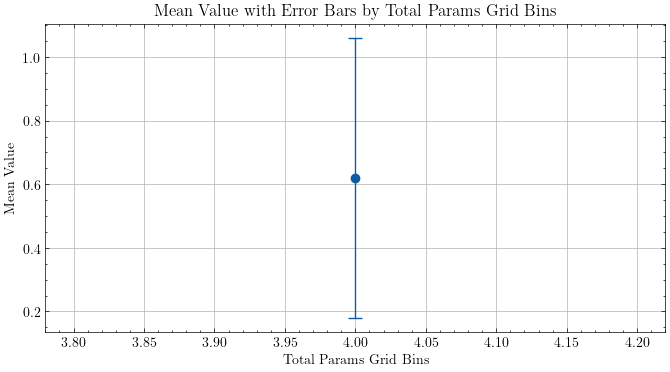

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'data' is your DataFrame and you have already created the bins
data["total_params_grids_bins"] = pd.cut(data["total_params_grids"], 10, labels=False)
data["total_params_grids_bins2"] = pd.cut(data["total_params_grids"], 10)

mean_values = data.groupby("total_params_grids_bins")["value"].mean()
std_values = data.groupby("total_params_grids_bins")["value"].std()

plt.figure(figsize=(8, 4))
plt.errorbar(mean_values.index, mean_values, yerr=std_values, fmt="o", capsize=5)

# Set the x-ticks to the bin labels
# plt.xticks(
#     mean_values.index,
#     [f"{interval}" for interval in data["total_params_grids_bins2"].cat.categories],
#     rotation=45,
# )

plt.title("Mean Value with Error Bars by Total Params Grid Bins")
plt.xlabel("Total Params Grid Bins")
plt.ylabel("Mean Value")
plt.grid()
plt.show()